In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/12sha/OneDrive/Desktop/Test/Placement_Data_Full_Class.csv")

In [3]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [4]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [6]:
df.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [7]:
df.columns

Index(['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s',
       'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p',
       'status', 'salary'],
      dtype='object')

## Question 1: Descriptive Statistics

Calculate the meaure of the central tendency for columns: 'ssc_p', 'hsc_p', 'degree_p', 'etest_p'

In [19]:
column = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p']

for col in column:
    central_tendency = [df[col].mean(), df[col].median(), df[col].mode()[0]]
    print(f"Central Tendency for {col}: Mean={central_tendency[0]}, Median={central_tendency[1]}, Mode={central_tendency[2]}")

Central Tendency for ssc_p: Mean=67.30339534883721, Median=67.0, Mode=62.0
Central Tendency for hsc_p: Mean=66.33316279069768, Median=65.0, Mode=63.0
Central Tendency for degree_p: Mean=66.37018604651163, Median=66.0, Mode=65.0
Central Tendency for etest_p: Mean=72.10055813953488, Median=71.0, Mode=60.0


 Create a histogram for the salary column. What does the distribution reveal about the salary level?

In [9]:
df['salary'].mean()

np.float64(288655.4054054054)

In [10]:
df['salary']= df['salary'].fillna(df['salary'].mean())

In [11]:
df['salary'].isnull().sum()

np.int64(0)

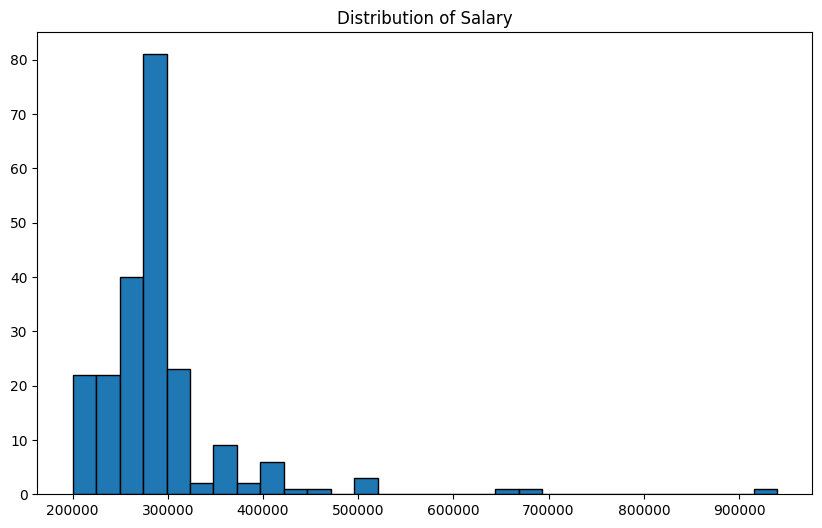

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(df['salary'], bins=30, edgecolor='black')
plt.title('Distribution of Salary')
plt.show()

From the distribution it can be seen that the salary in our dataset in concentrated between the range of 200000 - 320000 in which the salary range of 270000 - 30000 is the maximum candidates getting.

Calculate the correlation coefficients between 'ssc_p', 'hsc_p', 'degree_p' and 'etest_p'

In [20]:
correlation_matrix = df[['ssc_p', 'hsc_p', 'degree_p', 'etest_p']].corr()

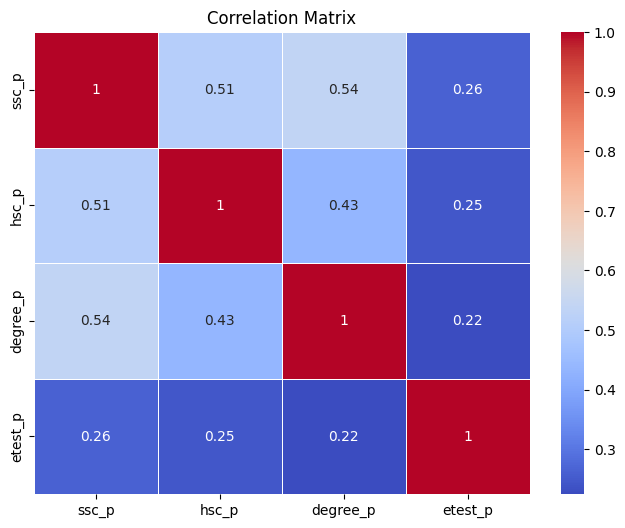

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

From the heatmap of the correlation matrix: there is a considerable amount of correlation between column (degree_p, ssc_p), (hsc_p, ssc_p), (degree_p, hsc_p). All other columns are also positively related but the correlation score is between 0.22 - 0.26

## Question 2: Data Cleaning and Preprocessing

Identify and handle any missing values in the dataset.

In [23]:
# df['salary']= df['salary'].fillna(df['salary'].mean())

In [24]:
df.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

Remark : Missing values were handles in the first question

Check for the outliers in the salary column. If the outliers are found, consider appropriate methods to handle them

In [34]:
columns1 = df.columns.drop(['sl_no', 'gender', 'workex', 'status', 'specialisation'])

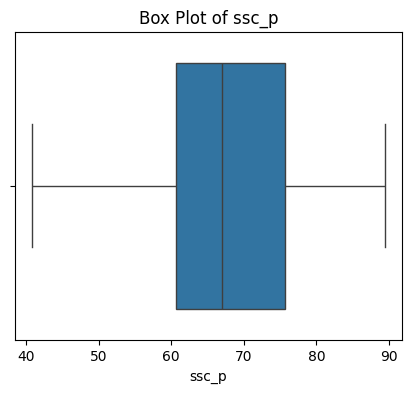

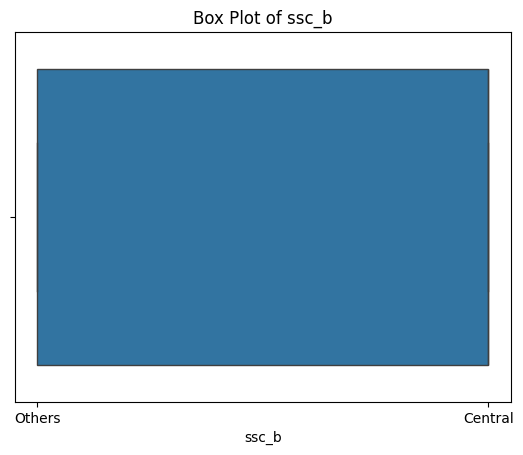

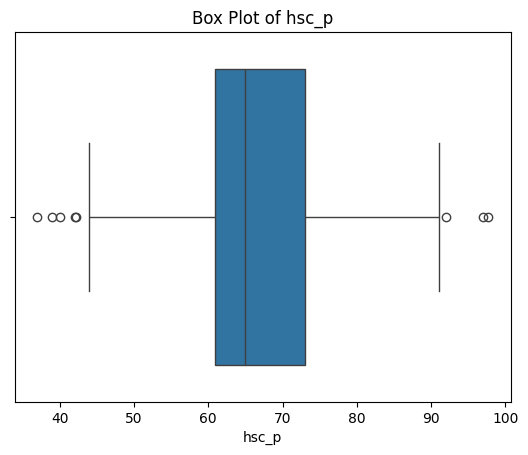

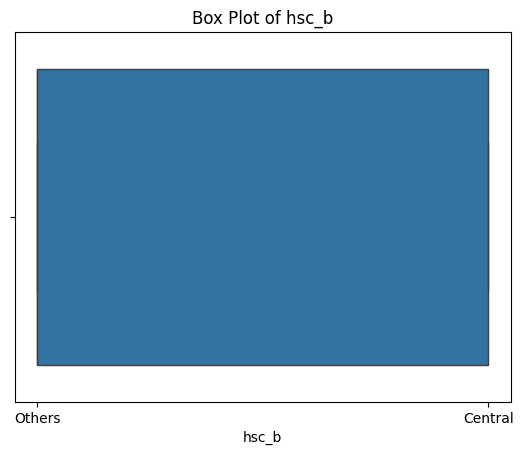

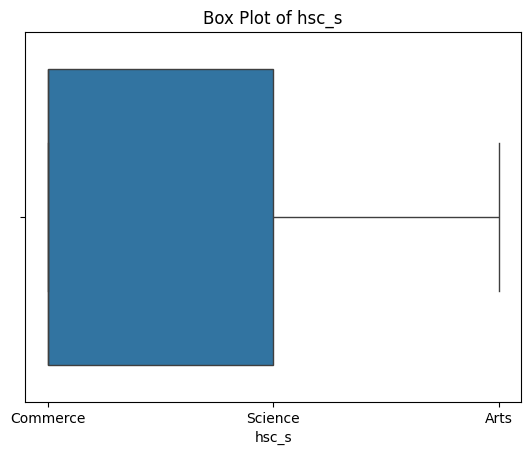

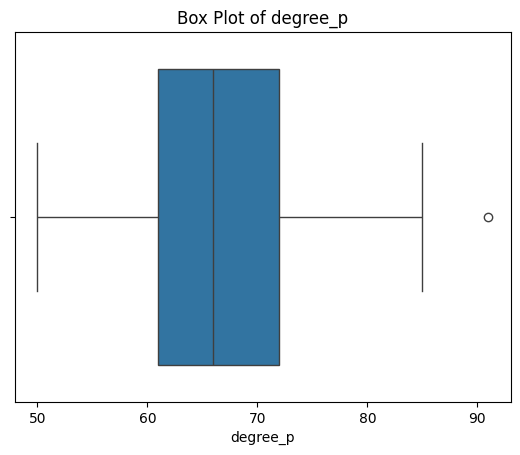

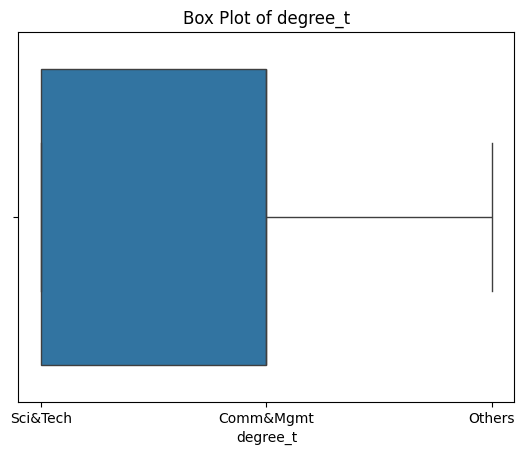

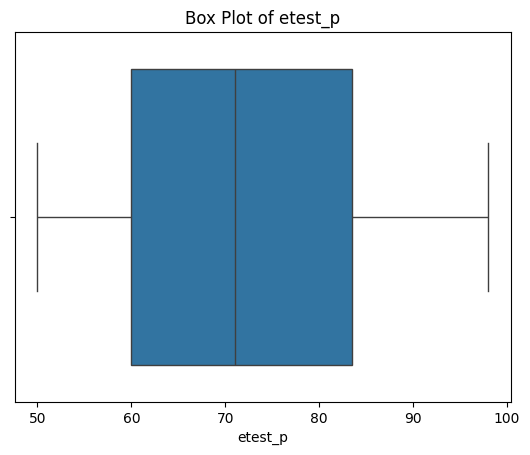

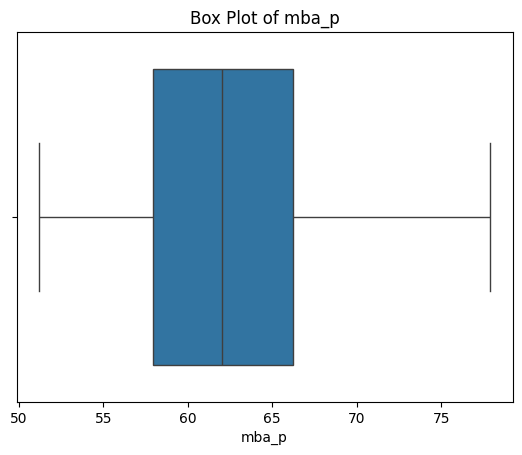

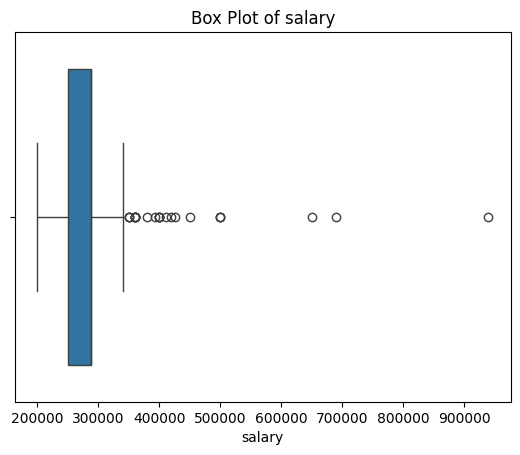

In [35]:
plt.figure(figsize=(5, 4))
for col in columns1:
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

The outliers are present in the columns : salary, hsc_p and degree_p

Convert categorical variables into numerical representations suitable for analysis

In [40]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns = categorical_columns.drop(['status', 'hsc_s'])   
print(categorical_columns)

Index(['gender', 'ssc_b', 'hsc_b', 'degree_t', 'workex', 'specialisation'], dtype='object')


In [41]:
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [42]:
df_encoded.head()

,sl_no,ssc_p,hsc_p,hsc_s,degree_p,etest_p,mba_p,status,salary,gender_M,ssc_b_Others,hsc_b_Others,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
0,1,67.00,91.00,Commerce,58.00,55.0,58.80,Placed,270000.000000,True,True,True,False,True,False,True
1,2,79.33,78.33,Science,77.48,86.5,66.28,Placed,200000.000000,True,False,True,False,True,True,False
2,3,65.00,68.00,Arts,64.00,75.0,57.80,Placed,250000.000000,True,False,False,False,False,False,False
3,4,56.00,52.00,Science,52.00,66.0,59.43,Not Placed,288655.405405,True,False,False,False,True,False,True
4,5,85.80,73.60,Commerce,73.30,96.8,55.50,Placed,425000.000000,True,False,False,False,False,False,False


Create a new column 'education_gap' that represents the difference between degree_p and hsc_p

In [43]:
df_encoded['education_gap'] = df_encoded['degree_p'] - df_encoded['hsc_p']

In [45]:
df_encoded.head()

,sl_no,ssc_p,hsc_p,hsc_s,degree_p,etest_p,mba_p,status,salary,gender_M,ssc_b_Others,hsc_b_Others,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR,education_gap
0,1,67.00,91.00,Commerce,58.00,55.0,58.80,Placed,270000.000000,True,True,True,False,True,False,True,-33.00
1,2,79.33,78.33,Science,77.48,86.5,66.28,Placed,200000.000000,True,False,True,False,True,True,False,-0.85
2,3,65.00,68.00,Arts,64.00,75.0,57.80,Placed,250000.000000,True,False,False,False,False,False,False,-4.00
3,4,56.00,52.00,Science,52.00,66.0,59.43,Not Placed,288655.405405,True,False,False,False,True,False,True,0.00
4,5,85.80,73.60,Commerce,73.30,96.8,55.50,Placed,425000.000000,True,False,False,False,False,False,False,-0.30


Convert the 'salary' column to a numeric type, handling any non- numeric values appropriately.

In [46]:
df_encoded['salary'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 215 entries, 0 to 214
Series name: salary
Non-Null Count  Dtype  
--------------  -----  
215 non-null    float64
dtypes: float64(1)
memory usage: 1.8 KB


Remark : The 'salary' column is already numeric

Convert categorical variables into numerical variables using appropriate encoding techniques.

In [47]:
df_encoded = pd.get_dummies(df_encoded, columns = ['status', 'hsc_s'], drop_first = True)

In [48]:
df_encoded.head()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,gender_M,ssc_b_Others,hsc_b_Others,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR,education_gap,status_Placed,hsc_s_Commerce,hsc_s_Science
0,1,67.00,91.00,58.00,55.0,58.80,270000.000000,True,True,True,False,True,False,True,-33.00,True,True,False
1,2,79.33,78.33,77.48,86.5,66.28,200000.000000,True,False,True,False,True,True,False,-0.85,True,False,True
2,3,65.00,68.00,64.00,75.0,57.80,250000.000000,True,False,False,False,False,False,False,-4.00,True,False,False
3,4,56.00,52.00,52.00,66.0,59.43,288655.405405,True,False,False,False,True,False,True,0.00,False,False,True
4,5,85.80,73.60,73.30,96.8,55.50,425000.000000,True,False,False,False,False,False,False,-0.30,True,True,False


Normalize the numerical scores (ssc_p, hsc_p, degree_p, etest_p, mba_p) to a standard scale.

In [50]:
numerical_columns = df_encoded.select_dtypes(include=['int64', 'float64']).columns
print(numerical_columns)

Index(['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary',
       'education_gap'],
      dtype='object')


In [51]:
import sklearn
from sklearn.preprocessing import StandardScaler

In [52]:
stScaler = StandardScaler()

In [53]:
X = df_encoded[numerical_columns]
X_scaled = stScaler.fit_transform(X)

## Question 3: EDA

Analyze the relation b/w gender and placement status. Is there a significant difference in placement rates between males and females?

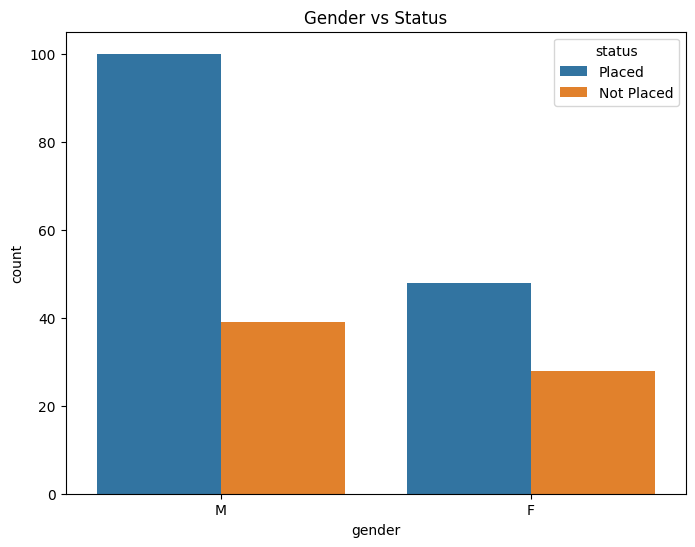

In [66]:
# Gender vs Status
plt.figure(figsize=(8, 6)) 
sns.countplot(x='gender', hue='status', data=df)
plt.title('Gender vs Status')
plt.show()

The number of Male candidates placed > Number of female candidates placed. But it is also to be noticed that number of female candidates is approximately half of the males candidates. And if we compare the ratio of female candidates placed and not placed to the same of male candidates, the placements are comparitively high in female candidates

Explore the impact of the board of education on placement. Are students from central or Other boards more likely to be placed?

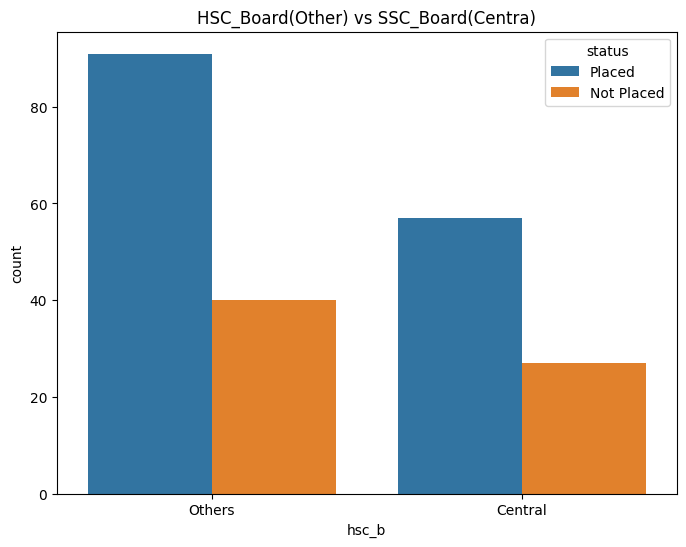

In [75]:
plt.figure(figsize=(8, 6)) 
sns.countplot(x='hsc_b',hue='status', data=df)
plt.title('HSC_Board(Other) vs SSC_Board(Centra)')
plt.show()

From the graph: The students of other board(HSC) are more likely to be placed as compared to the students of Central Board(SSC)